In [948]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import davies_bouldin_score



In [949]:

# 1. LOAD DATA

df = pd.read_csv("final_stop_features2.csv")

drop_cols = ["vehicle_file", "class", "class_id","mean_x","mean_y", "start_frame","end_frame","post_vel","pre_vel", "displacement"]
X = df.drop(columns=drop_cols)

# keep only numeric
X = X.select_dtypes(include=[np.number])


# 2. SCALE

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [950]:
# 3. PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Reduced dimensions:", X_pca.shape[1])
print("Explained variance:", sum(pca.explained_variance_ratio_))

Reduced dimensions: 4
Explained variance: 0.9999999999999998


In [951]:
# 4. KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df["cluster"] = clusters

print("Cluster distribution:")
print(df["cluster"].value_counts())

Cluster distribution:
cluster
0    539
1     66
Name: count, dtype: int64


In [952]:
numeric_cols = X.columns
cluster_summary = df.groupby("cluster")[numeric_cols].mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         duration_frames  duration_sec  pos_variance  mean_vel   max_vel
cluster                                                                 
0             156.864564      6.536024      2.729359  1.190135  2.421713
1            1282.484848     53.436869      6.337710  0.761556  2.440133


In [953]:
key_feature = "duration_sec"

cluster_means = df.groupby("cluster")[key_feature].mean()
print("Cluster means (duration_sec):")
print(cluster_means)

hard_cluster = cluster_means.idxmax()

df["predicted_label"] = df["cluster"].apply(
    lambda x: "hard" if x == hard_cluster else "momentary"
)


Cluster means (duration_sec):
cluster
0     6.536024
1    53.436869
Name: duration_sec, dtype: float64


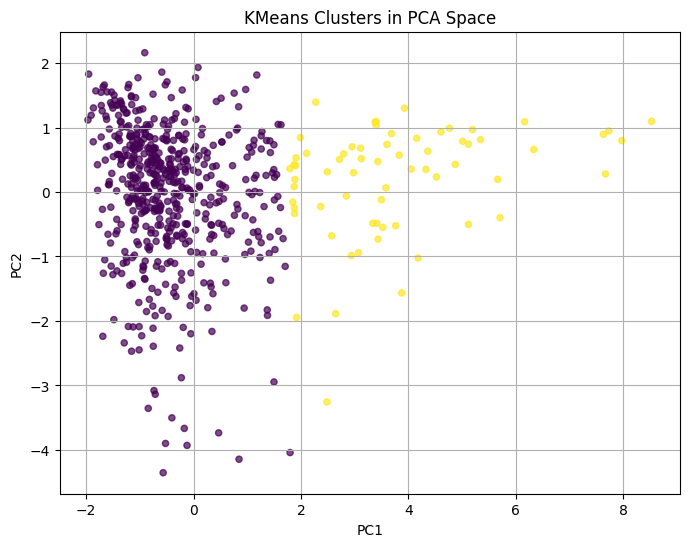

In [954]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=20,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters in PCA Space")
plt.grid(True)
plt.show()

In [955]:
score = silhouette_score(X_pca, clusters)
DB_Score = davies_bouldin_score(X_pca, clusters)
print("\nSilhouette Score:", score)
print(DB_Score)


Silhouette Score: 0.5221136637652269
0.833897150707531


In [956]:
y = df["cluster"]

In [957]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [958]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [959]:
y_pred = clf.predict(X_test)

In [960]:
model = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [961]:
y_pred = model.predict(X_test)

In [962]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9917355371900827

Confusion Matrix:
[[107   1]
 [  0  13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       108
           1       0.93      1.00      0.96        13

    accuracy                           0.99       121
   macro avg       0.96      1.00      0.98       121
weighted avg       0.99      0.99      0.99       121



In [963]:
X_train_LR, X_test_LR, y_train_LR, y_test_LR = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled_LR = scaler.fit_transform(X_train_LR)
X_test_scaled_LR = scaler.transform(X_test_LR)

In [964]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled_LR, y_train_LR)
y_pred_LR = model.predict(X_test_scaled_LR)

In [965]:
print("Accuracy:", accuracy_score(y_test_LR, y_pred_LR))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_LR, y_pred_LR))

print("\nClassification Report:")
print(classification_report(y_test_LR, y_pred_LR))

Accuracy: 1.0

Confusion Matrix:
[[108   0]
 [  0  13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00        13

    accuracy                           1.00       121
   macro avg       1.00      1.00      1.00       121
weighted avg       1.00      1.00      1.00       121



### Interpretation

* Features with positive weights define Hard Stops. And Hard stops are primarily characterized by longer temporal duration.

* Features with negative weights define Momentary Stops. Momentary stops are associated with higher and more persistent velocity behavior, indicating incomplete or brief stopping events.

* Spatial features contribute very little to separating the two classes.

In [966]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_[0]
}).sort_values(by="weight", ascending=False)

print(feature_importance)

           feature    weight
0  duration_frames  2.703070
1     duration_sec  2.703070
2     pos_variance  1.634467
4          max_vel  0.375317
3         mean_vel -1.002294


In [967]:
pca = PCA(n_components=2)
X_pca_LR = pca.fit_transform(X_scaled)

x_min, x_max = X_pca_LR[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca_LR[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points_pca = np.c_[xx.ravel(), yy.ravel()]
grid_points_original = pca.inverse_transform(grid_points_pca)

Z = model.predict(grid_points_original)
Z = Z.reshape(xx.shape)



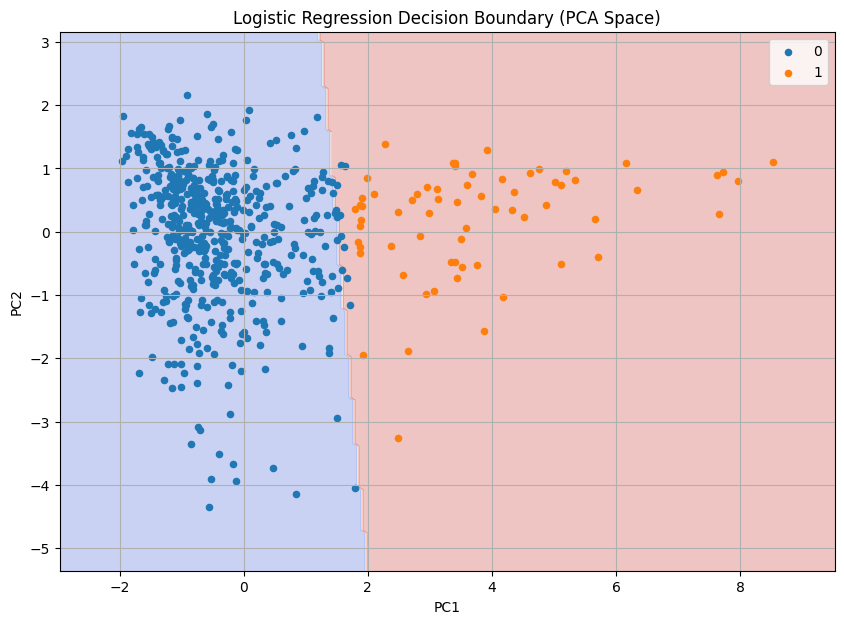

In [968]:
plt.figure(figsize=(10, 7))

# Decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Data points
for label in np.unique(y):
    idx = y == label
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=str(label),
        s=20
    )

plt.title("Logistic Regression Decision Boundary (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

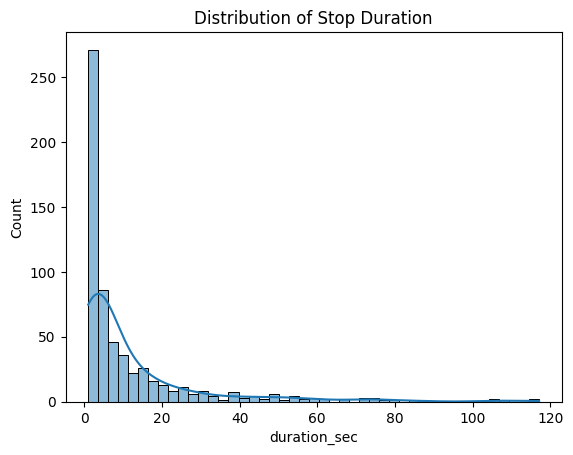

In [969]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['duration_sec'], kde=True)
plt.title("Distribution of Stop Duration")
plt.show()